# Évaluation du Modèle Shortage

Ce notebook évalue le modèle de prédiction des pénuries de sang (shortage_model) en utilisant des métriques de classification et des courbes.

In [1]:
# Import des bibliothèques nécessaires
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# Configuration pour les plots
plt.style.use('default')
sns.set_palette('husl')

In [4]:
# Définition des chemins
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # Ajuster si nécessaire

DATASET_PATH = os.path.join(BASE_DIR, "..", "data", "shortage_model_dataset.csv")
MODELS_DIR = os.path.join(BASE_DIR, "..", "models")
MODEL_PATH = os.path.join(MODELS_DIR, "shortage_model.joblib")
BLOOD_ENCODER_PATH = os.path.join(MODELS_DIR, "blood_type_encoder.joblib")
FEATURES_PATH = os.path.join(BASE_DIR, "..", "shortage_model_features.json")

print("Chemins définis :")
print(f"Dataset: {DATASET_PATH}")
print(f"Modèle: {MODEL_PATH}")
print(f"Encodeur: {BLOOD_ENCODER_PATH}")
print(f"Features: {FEATURES_PATH}")

Chemins définis :
Dataset: c:\Donify\project-root\ai\notebooks\..\data\shortage_model_dataset.csv
Modèle: c:\Donify\project-root\ai\notebooks\..\models\shortage_model.joblib
Encodeur: c:\Donify\project-root\ai\notebooks\..\models\blood_type_encoder.joblib
Features: c:\Donify\project-root\ai\notebooks\..\shortage_model_features.json


In [8]:
# Chargement du modèle et de l'encodeur
model = joblib.load(MODEL_PATH)
blood_encoder = joblib.load(BLOOD_ENCODER_PATH)

with open(FEATURES_PATH, 'r', encoding='utf-8') as f:
    features = json.load(f)

print("✅ Modèle chargé")
print("✅ Encodeur chargé")
print("✅ Features chargées:", features)

✅ Modèle chargé
✅ Encodeur chargé
✅ Features chargées: ['blood_type_encoded', 'total_requested_bags', 'total_donated_bags', 'gap_bags', 'current_stock_bags', 'stock_coverage_days', 'month', 'is_weekend', 'is_summer', 'is_ramadan_like', 'req_7d', 'don_7d']


C:\Users\karim\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Chargement du dataset
df = pd.read_csv(DATASET_PATH)

print("✅ Dataset chargé")
print("Taille:", df.shape)
print(df.head())

✅ Dataset chargé
Taille: (58400, 16)
         date  hospital_id blood_type  total_requested_bags  \
0  2024-01-01  HOSPITAL_01         A+                    27   
1  2024-01-02  HOSPITAL_01         A+                    23   
2  2024-01-03  HOSPITAL_01         A+                    23   
3  2024-01-04  HOSPITAL_01         A+                    29   
4  2024-01-05  HOSPITAL_01         A+                    15   

   total_donated_bags  gap_bags  current_stock_bags  stock_coverage_days  \
0                  21         6                  57                 2.11   
1                  19         4                  53                 2.30   
2                  18         5                  48                 2.09   
3                  18        11                  37                 1.28   
4                  13         2                  35                 2.33   

   month  is_weekend  is_summer  is_ramadan_like  req_7d  don_7d  \
0      1           0          0                0      27   

In [6]:
# Prétraitement des données (même que dans l'entraînement)
df = df.dropna().copy()

numeric_columns = [
    "total_requested_bags",
    "total_donated_bags",
    "gap_bags",
    "current_stock_bags",
    "stock_coverage_days",
    "month",
    "is_weekend",
    "is_summer",
    "is_ramadan_like",
    "req_7d",
    "don_7d",
    "shortage_label"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().copy()

df["shortage_label"] = df["shortage_label"].astype(int)
df["is_weekend"] = df["is_weekend"].astype(int)
df["is_summer"] = df["is_summer"].astype(int)
df["is_ramadan_like"] = df["is_ramadan_like"].astype(int)
df["month"] = df["month"].astype(int)

# Encodage blood_type
df["blood_type_encoded"] = blood_encoder.transform(df["blood_type"])

print("✅ Prétraitement terminé")
print("Nouvelle taille:", df.shape)

✅ Prétraitement terminé
Nouvelle taille: (58400, 17)


In [7]:
# Séparation des features et target
target = "shortage_label"
X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['blood_type_encoded', 'total_requested_bags', 'total_donated_bags', 'gap_bags', 'current_stock_bags', 'stock_coverage_days', 'month', 'is_weekend', 'is_summer', 'is_ramadan_like', 'req_7d', 'don_7d']
Target: shortage_label
X shape: (58400, 12)
y shape: (58400,)


In [9]:
# Split train/test (même random_state que l'entraînement)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Split terminé")
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

✅ Split terminé
Train: (46720, 12) (46720,)
Test: (11680, 12) (11680,)


In [10]:
# Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("✅ Prédictions effectuées")

✅ Prédictions effectuées


In [11]:
# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("===== MÉTRIQUES DU MODÈLE =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

===== MÉTRIQUES DU MODÈLE =====
Accuracy  : 0.9422
Precision : 0.9650
Recall    : 0.9687
F1-score  : 0.9668
ROC-AUC   : 0.9565


In [12]:
# Rapport de classification
print("===== RAPPORT DE CLASSIFICATION =====")
print(classification_report(y_test, y_pred, zero_division=0))

===== RAPPORT DE CLASSIFICATION =====
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1530
           1       0.96      0.97      0.97     10150

    accuracy                           0.94     11680
   macro avg       0.88      0.87      0.87     11680
weighted avg       0.94      0.94      0.94     11680



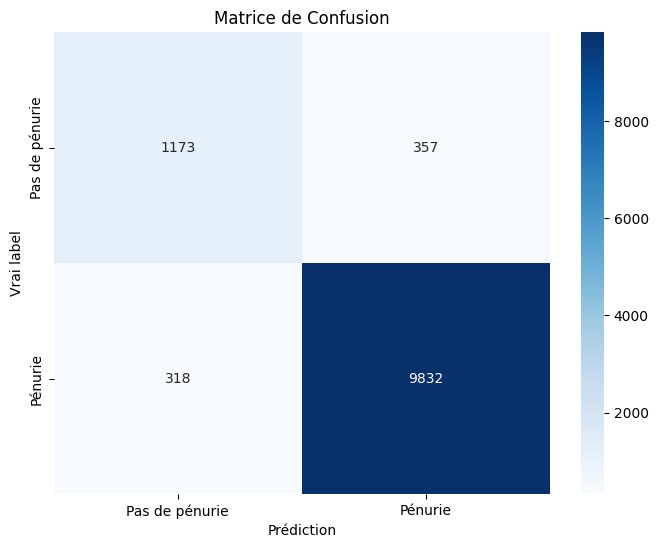

In [13]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pas de pénurie', 'Pénurie'], 
            yticklabels=['Pas de pénurie', 'Pénurie'])
plt.title('Matrice de Confusion')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

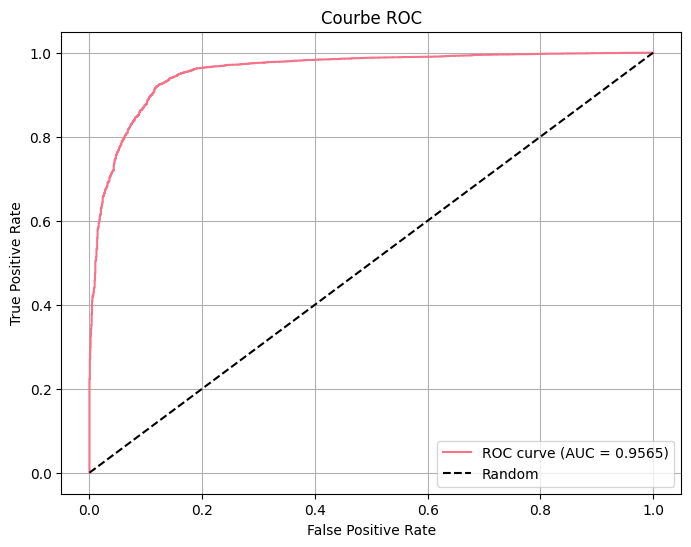

In [14]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.grid(True)
plt.show()

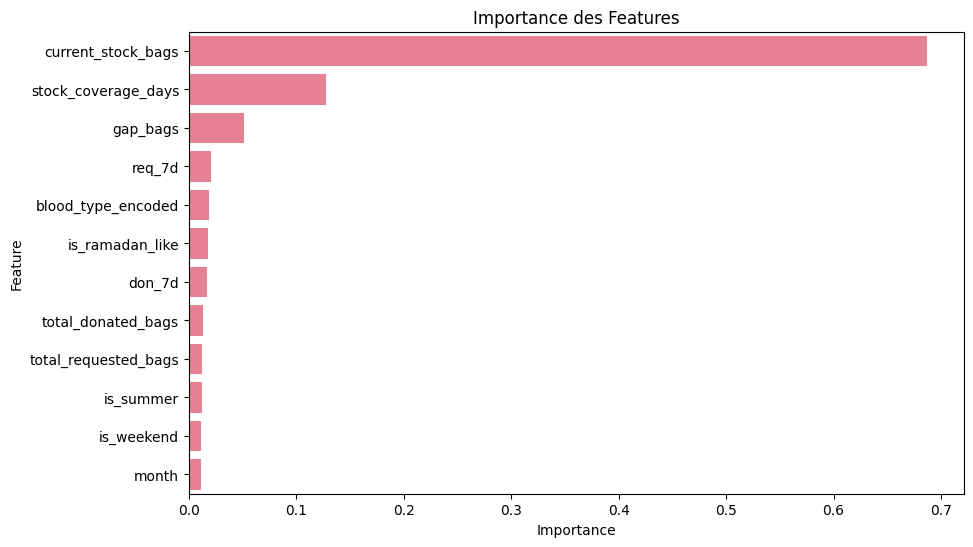

===== IMPORTANCE DES FEATURES =====
                 feature  importance
4     current_stock_bags    0.686937
5    stock_coverage_days    0.127409
3               gap_bags    0.050841
10                req_7d    0.020612
0     blood_type_encoded    0.018529
9        is_ramadan_like    0.017819
11                don_7d    0.016991
2     total_donated_bags    0.013132
1   total_requested_bags    0.012582
8              is_summer    0.012144
7             is_weekend    0.011724
6                  month    0.011281


In [15]:
# Importance des features
feature_importances = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importances)
plt.title("Importance des Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("===== IMPORTANCE DES FEATURES =====")
print(feature_importances)